# SPX volatility surface — from the raw CBOE chain to a clean smile

An **evidence notebook**: how a raw SPX option chain becomes a clean IV smile + term
structure, and *why* each choice was made. Decisions are logged in `docs/DECISIONS.md`.

- **IV source** — CBOE's published `cboe_iv`, to validate the clean → slice → surface
  pipeline (ADR 006). Our own Black-Scholes solver is a later milestone.
- **Data** — one SPX snapshot off CBOE's delayed feed (timestamp in the first cell).
  CBOE's terms forbid redistribution, so the raw chain is gitignored (ADR 001) — the
  **rendered outputs are the deliverable**.
- **Read, don't re-run** — the prose is written to *this* snapshot. To run it live:
  `download_chain()`, then point `PINNED` at your date (your market won't match the
  narrative). Expiries pick by nearest-day-target, so it survives any snapshot.

In [56]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.data import load_chain, chain_to_frame, download_chain
from engine.filters import bidask_mask
from engine.surface import forward_by_expiry, implied_forwards, select_otm
# (staleness_mask / volume_mask stay in engine.filters but aren't v1 filters — see §4)

# colorblind-safe palette (Wong): identity, kept-vs-dropped, roots, maturity ramp
C_CALL, C_PUT = "#0173B2", "#DE8F05"
C_KEEP, C_DROP = "#029E73", "#BBBBBB"
C_SPX, C_SPXW = "#CC3311", "#0077BB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
# --- the one snapshot this analysis is built on (raw chain gitignored, ADR 001) ---
# To run on your own data: download_chain() to fetch+save a snapshot, then set PINNED to
# its date. load_chain reads disk only and raises FileNotFoundError if you don't have it.
PINNED = "2026-07-13"
raw = load_chain(PINNED)
df  = chain_to_frame(raw)

ASOF_TS = df.attrs["asof"]                    # full quote timestamp — the provenance stamp
ASOF    = ASOF_TS.normalize()                 # midnight, for day counts downstream
SPOT    = df.attrs["spot"]                    # cash index level at the snapshot

print(f"SPX chain as of {ASOF_TS}  (CBOE delayed feed)")
print(f"{len(df):,} contracts | spot {SPOT:,.1f} | "
      f"roots {df['root'].unique().tolist()} | {df['expiry'].nunique()} expiries")

SPX chain as of 2026-07-13 21:19:31  (CBOE delayed feed)
29,486 contracts | spot 7,515.3 | roots ['SPX', 'SPXW'] | 56 expiries


In [58]:
# --- helpers: day counts, target-driven expiry picking, and the clean pipeline ---

def days_to(exp) -> int:
    """Calendar days from the snapshot to an expiry."""
    return int((pd.Timestamp(exp) - ASOF).days)


def nearest_expiry(expiries, target_days: int):
    """The listed expiry closest to `target_days` out (never a hardcoded date)."""
    exps = pd.DatetimeIndex(pd.Series(expiries).drop_duplicates())
    d = (exps - ASOF).days.to_numpy()
    return exps[np.abs(d - target_days).argmin()]


def build_clean(frame, r: float = 0.04):
    """Raw chain -> clean OTM quotes on a moneyness axis (the v1 pipeline, ADR 008).

    bid/ask>0  ->  parity forward per expiry  ->  keep the OTM side  ->  moneyness
    m = ln(K/F). Adds columns F and m. (Trade-count filters — staleness, volume — are
    dropped from v1: they discard tight never-traded quotes, which are fine off the mid.
    A spread-based liquidity filter is the deferred next step.)
    """
    d = frame[bidask_mask(frame)].copy()
    d["F"] = d["expiry"].map(forward_by_expiry(d, r))
    d = d.dropna(subset=["F"])
    d = d[select_otm(d)].copy()
    d["m"] = np.log(d["strike"] / d["F"])
    return d


def pick_slice(clean, target_days: int):
    """Nearest-to-target expiry, preferring SPXW on overlap (the root-blend rule, ADR 004).

    Returns (expiry, days, slice_frame, root).
    """
    exp = nearest_expiry(clean["expiry"], target_days)
    sl = clean[clean["expiry"] == exp]
    root = "SPXW" if (sl["root"] == "SPXW").any() else "SPX"
    return exp, days_to(exp), sl[sl["root"] == root], root


CLEAN = build_clean(df)
print(f"clean OTM quotes: {len(CLEAN):,} across {CLEAN['expiry'].nunique()} expiries")

clean OTM quotes: 13,575 across 56 expiries


## 1. Coverage — two roots, two jobs

Each dot is one expiry: how many clean options it lists. The two roots split the
maturity axis:

- **SPXW** (PM-settled) — weeklies out to ~1yr. *Thin per date, but every week* → near-term granularity.
- **SPX** (AM-settled) — monthlies, quarterlies, LEAPS to ~2031; no weeklies. *Rich per date, but sparse.*

So we **blend** them (ADR 004): SPXW near, SPX long end. Only **5 dates list both** — at
those we default SPXW, which covers the practical smile (to ~±1 log-moneyness); SPX's
extra strikes are exotic deep tail (down to 0.05× spot) that v1 doesn't need.

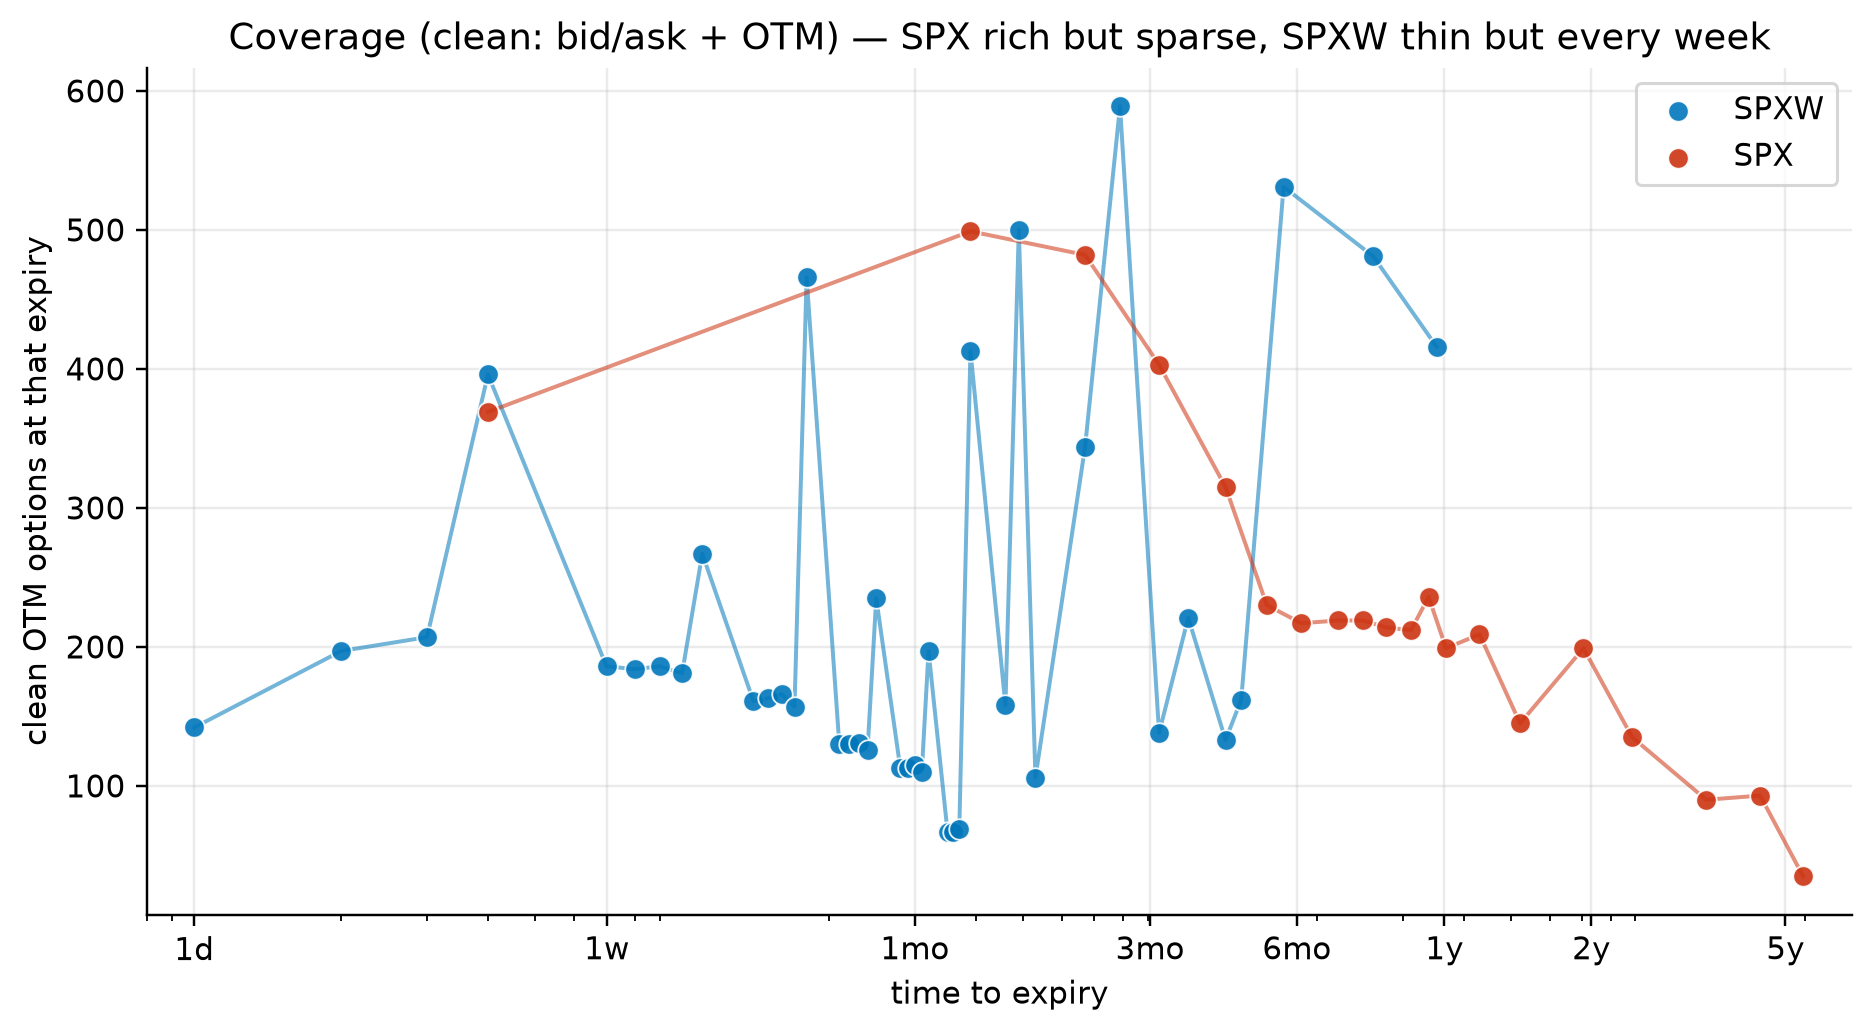

the clean pipeline keeps 13,575 of 29,486 listed contracts (46%)


In [67]:
# coverage of the CLEAN pipeline output (bid/ask + OTM), one point per expiry
cov = CLEAN.groupby(["root", "expiry"]).size().rename("n").reset_index()
cov["days"] = (cov["expiry"] - ASOF).dt.days
cov = cov[cov["days"] >= 1]                       # drop 0DTE (undefined on a log axis)

fig, ax = plt.subplots(figsize=(10, 5))
for root, c in [("SPXW", C_SPXW), ("SPX", C_SPX)]:
    s = cov[cov["root"] == root].sort_values("days")
    ax.plot(s["days"], s["n"], color=c, lw=1.3, alpha=0.55, zorder=2)          # guide line
    ax.scatter(s["days"], s["n"], s=45, color=c, label=root, alpha=0.9,
               edgecolor="white", linewidth=0.6, zorder=3)                     # the data
ax.set_xscale("log")
ax.set_xticks([1, 7, 30, 91, 182, 365, 730, 1825])
ax.set_xticklabels(["1d", "1w", "1mo", "3mo", "6mo", "1y", "2y", "5y"])
ax.set_xlim(0.8, 2500)
ax.set_xlabel("time to expiry")
ax.set_ylabel("clean OTM options at that expiry")
ax.set_title("Coverage (clean: bid/ask + OTM) — SPX rich but sparse, SPXW thin but every week")
ax.legend()
plt.show()

print(f"the clean pipeline keeps {len(CLEAN):,} of {len(df):,} listed contracts "
      f"({len(CLEAN)/len(df):.0%})")

## 2. Convergence — the blend is seamless

Where both roots list the *same* expiry we can difference their IVs strike-by-strike.
Near-term the AM/PM settlement gap makes them disagree (~0.4 vol pts a few days out);
by a few months the median disagreement collapses to ~0.05 vol pts. So handing the near
term to SPXW and the long end to SPX introduces no visible seam — **they've already
converged by the maturity where the handoff happens.**

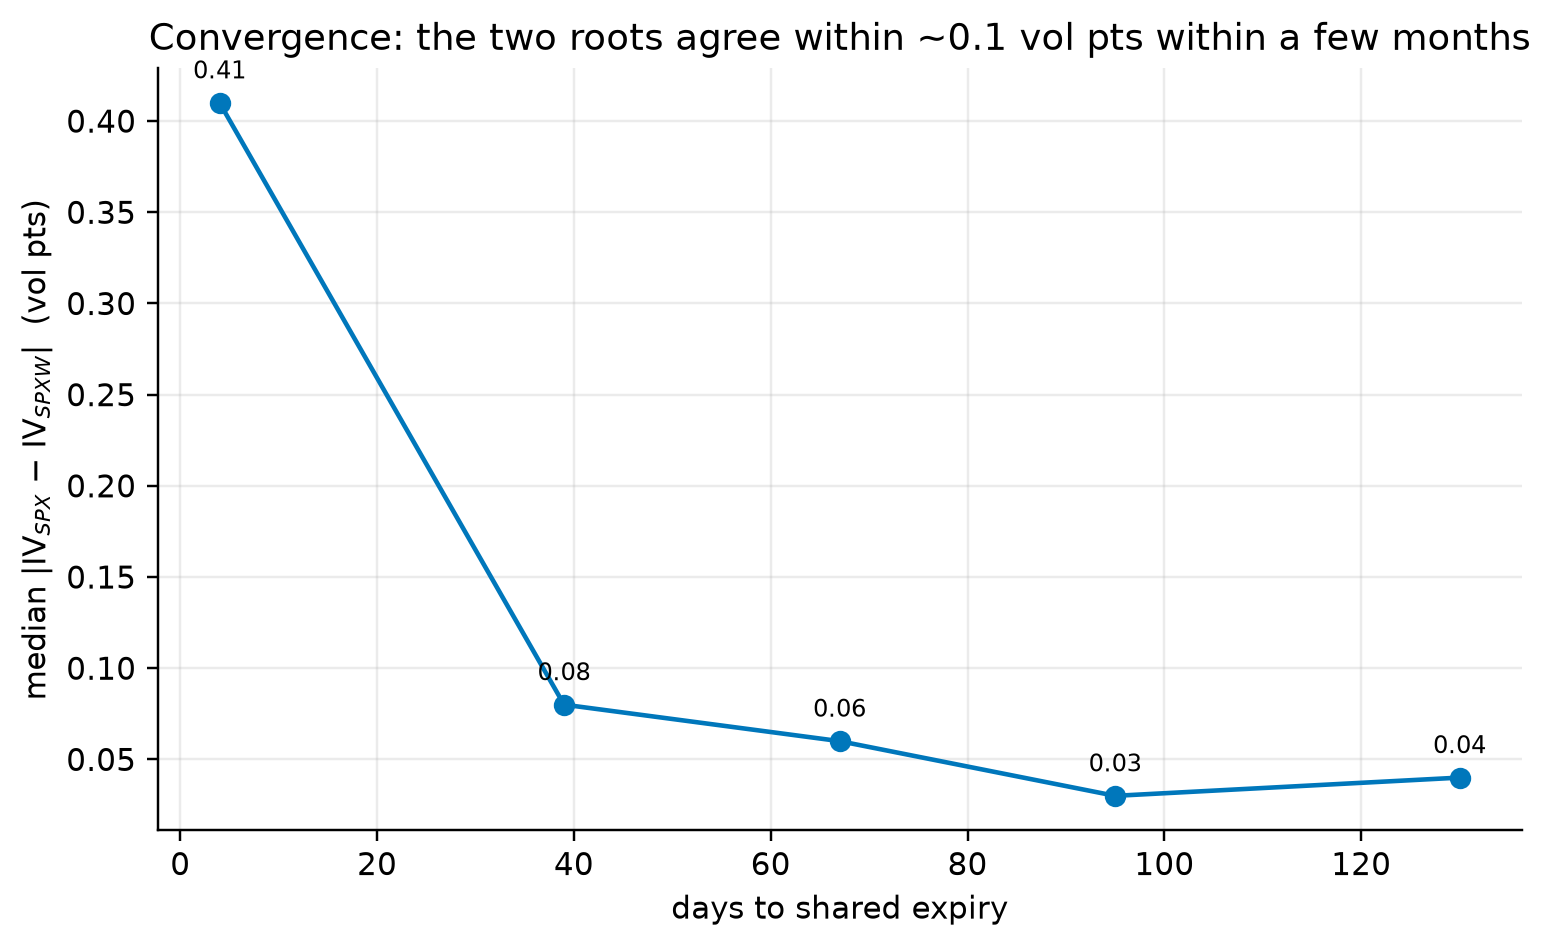

In [60]:
qc = df[bidask_mask(df)].copy()
qc["F"] = qc["expiry"].map(forward_by_expiry(qc))
qc = qc.dropna(subset=["F"])
qc = qc[select_otm(qc) & (qc["cboe_iv"] > 0)]          # compare only reliable OTM IVs

piv = qc.pivot_table(index=["expiry", "type", "strike"], columns="root", values="cboe_iv")
piv = piv.dropna(subset=["SPX", "SPXW"])                # strikes listed under BOTH roots
piv["ad"] = (piv["SPX"] - piv["SPXW"]).abs() * 100      # vol points
conv = piv.groupby("expiry")["ad"].median()
cd = pd.DataFrame({"days": [days_to(e) for e in conv.index], "vp": conv.values}).sort_values("days")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cd["days"], cd["vp"], "-o", color=C_SPXW, ms=6)
for _, row in cd.iterrows():
    ax.annotate(f"{row['vp']:.2f}", (row["days"], row["vp"]),
                textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")
ax.set_xlabel("days to shared expiry")
ax.set_ylabel(r"median |IV$_{SPX}$ − IV$_{SPXW}$|  (vol pts)")
ax.set_title("Convergence: the two roots agree within ~0.1 vol pts within a few months")
plt.show()

## 3. The forward, from the options themselves

The moneyness axis needs a forward `F` per expiry. Rather than guess SPX's dividend
yield, read `F` straight off prices via **put-call parity**: for any strike,
`F = K + e^{rT}(C − P)` (ADR 003). Because `C − P` is vol-independent, every liquid
strike of an expiry should imply the *same* `F` — so the spread across strikes is a
built-in quality check. We take the median. `r` is the only free input.

Below: the call/put pairs for a ~30-day expiry, then `F` per strike — it should be flat.

In [61]:
exp30, d30, _, root30 = pick_slice(CLEAN, 30)
qf = df[(df["expiry"] == exp30) & (df["root"] == root30) & bidask_mask(df)]
imp = implied_forwards(qf)
print(f"{root30} {pd.Timestamp(exp30).date()} ({d30}d): {len(imp)} call+put pairs, "
      f"F = {imp['F'].median():.1f} ± {imp['F'].std():.2f} across strikes")
imp.head()

SPXW 2026-08-12 (30d): 115 call+put pairs, F = 7536.3 ± 0.53 across strikes


type,root,expiry,strike,T,F
0,SPXW,2026-08-12,3400.0,0.082192,7536.150976
1,SPXW,2026-08-12,3600.0,0.082192,7536.194665
2,SPXW,2026-08-12,3800.0,0.082192,7537.191482
3,SPXW,2026-08-12,4000.0,0.082192,7536.256960
4,SPXW,2026-08-12,4200.0,0.082192,7536.325731


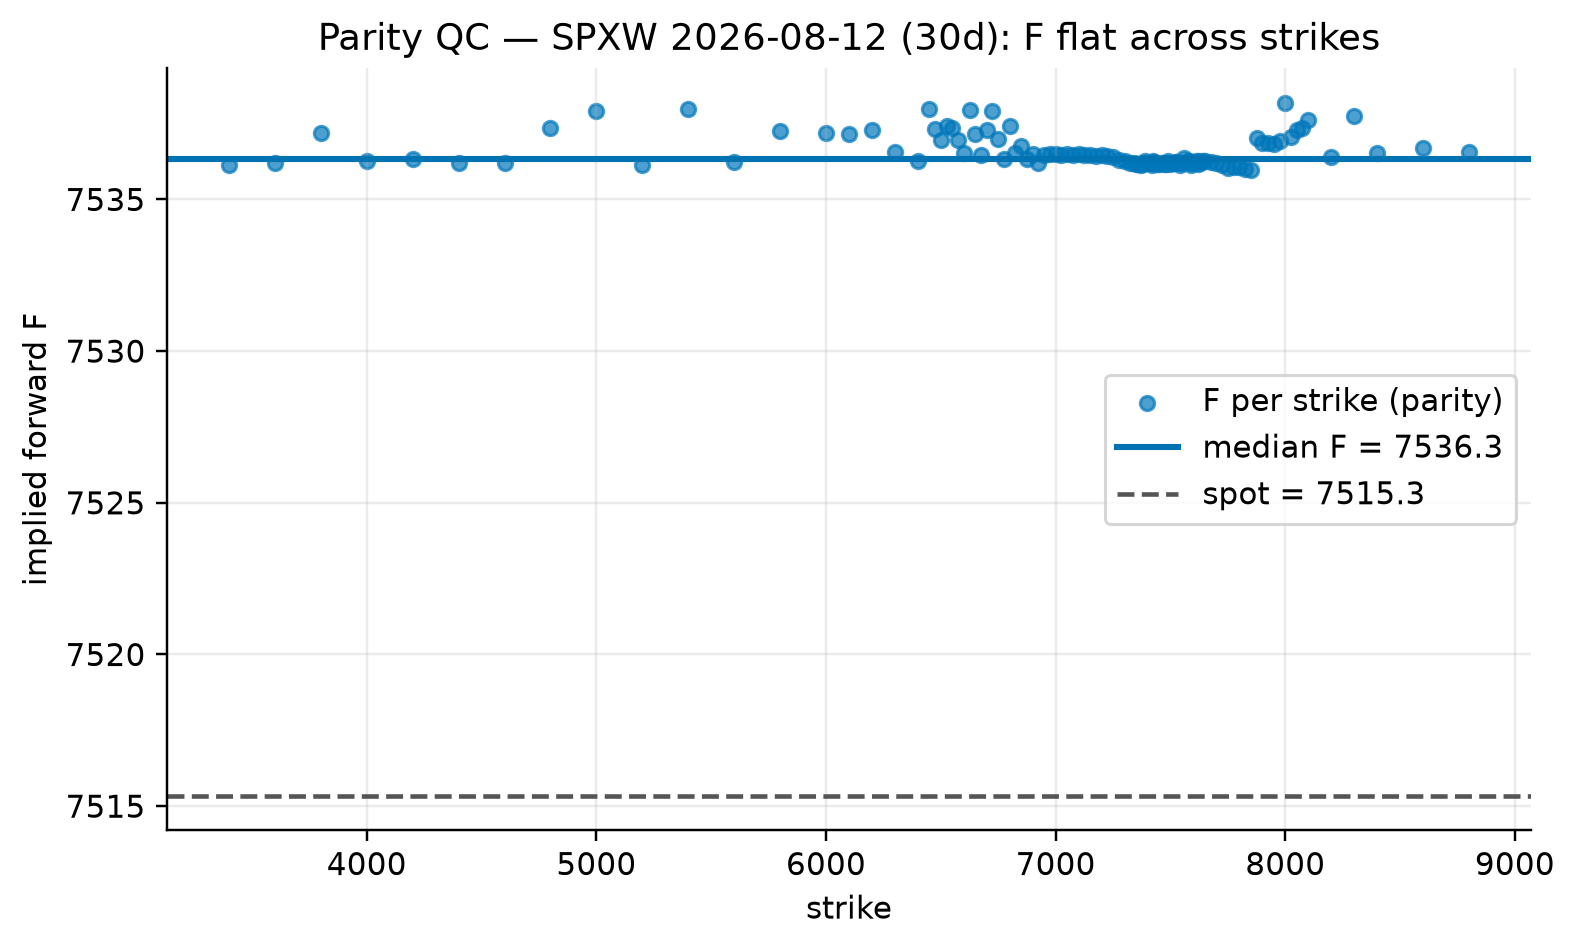

In [62]:
Fmed = imp["F"].median()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(imp["strike"], imp["F"], s=22, color=C_SPXW, alpha=0.7, label="F per strike (parity)")
ax.axhline(Fmed, color=C_CALL, lw=2, label=f"median F = {Fmed:.1f}")
ax.axhline(SPOT, color="#555555", ls="--", lw=1.5, label=f"spot = {SPOT:.1f}")
ax.set_xlabel("strike")
ax.set_ylabel("implied forward F")
ax.set_title(f"Parity QC — {root30} {pd.Timestamp(exp30).date()} ({d30}d): F flat across strikes")
ax.legend()
plt.show()

## 4. Filters — raw chain to clean smile

Two filters turn the raw chain into a clean smile, shown on one ~30-day expiry
(left = every listed contract, right = filtered):

- **bid/ask > 0** — drop one-sided / no-quote contracts (the zero-IV floor along the bottom).
- **OTM selection** — keep the out-of-money side of each strike (puts below the forward,
  calls above). The ITM twin is parity-redundant and wider-spread — it's the doubled inner
  branch near ATM that disappears.

*Trade-count filters (volume, staleness) were tried and dropped: they discard tight
never-traded market-maker quotes, which are fine when you price off the mid. A spread-based
liquidity filter is the deferred next step (ADR 008).*

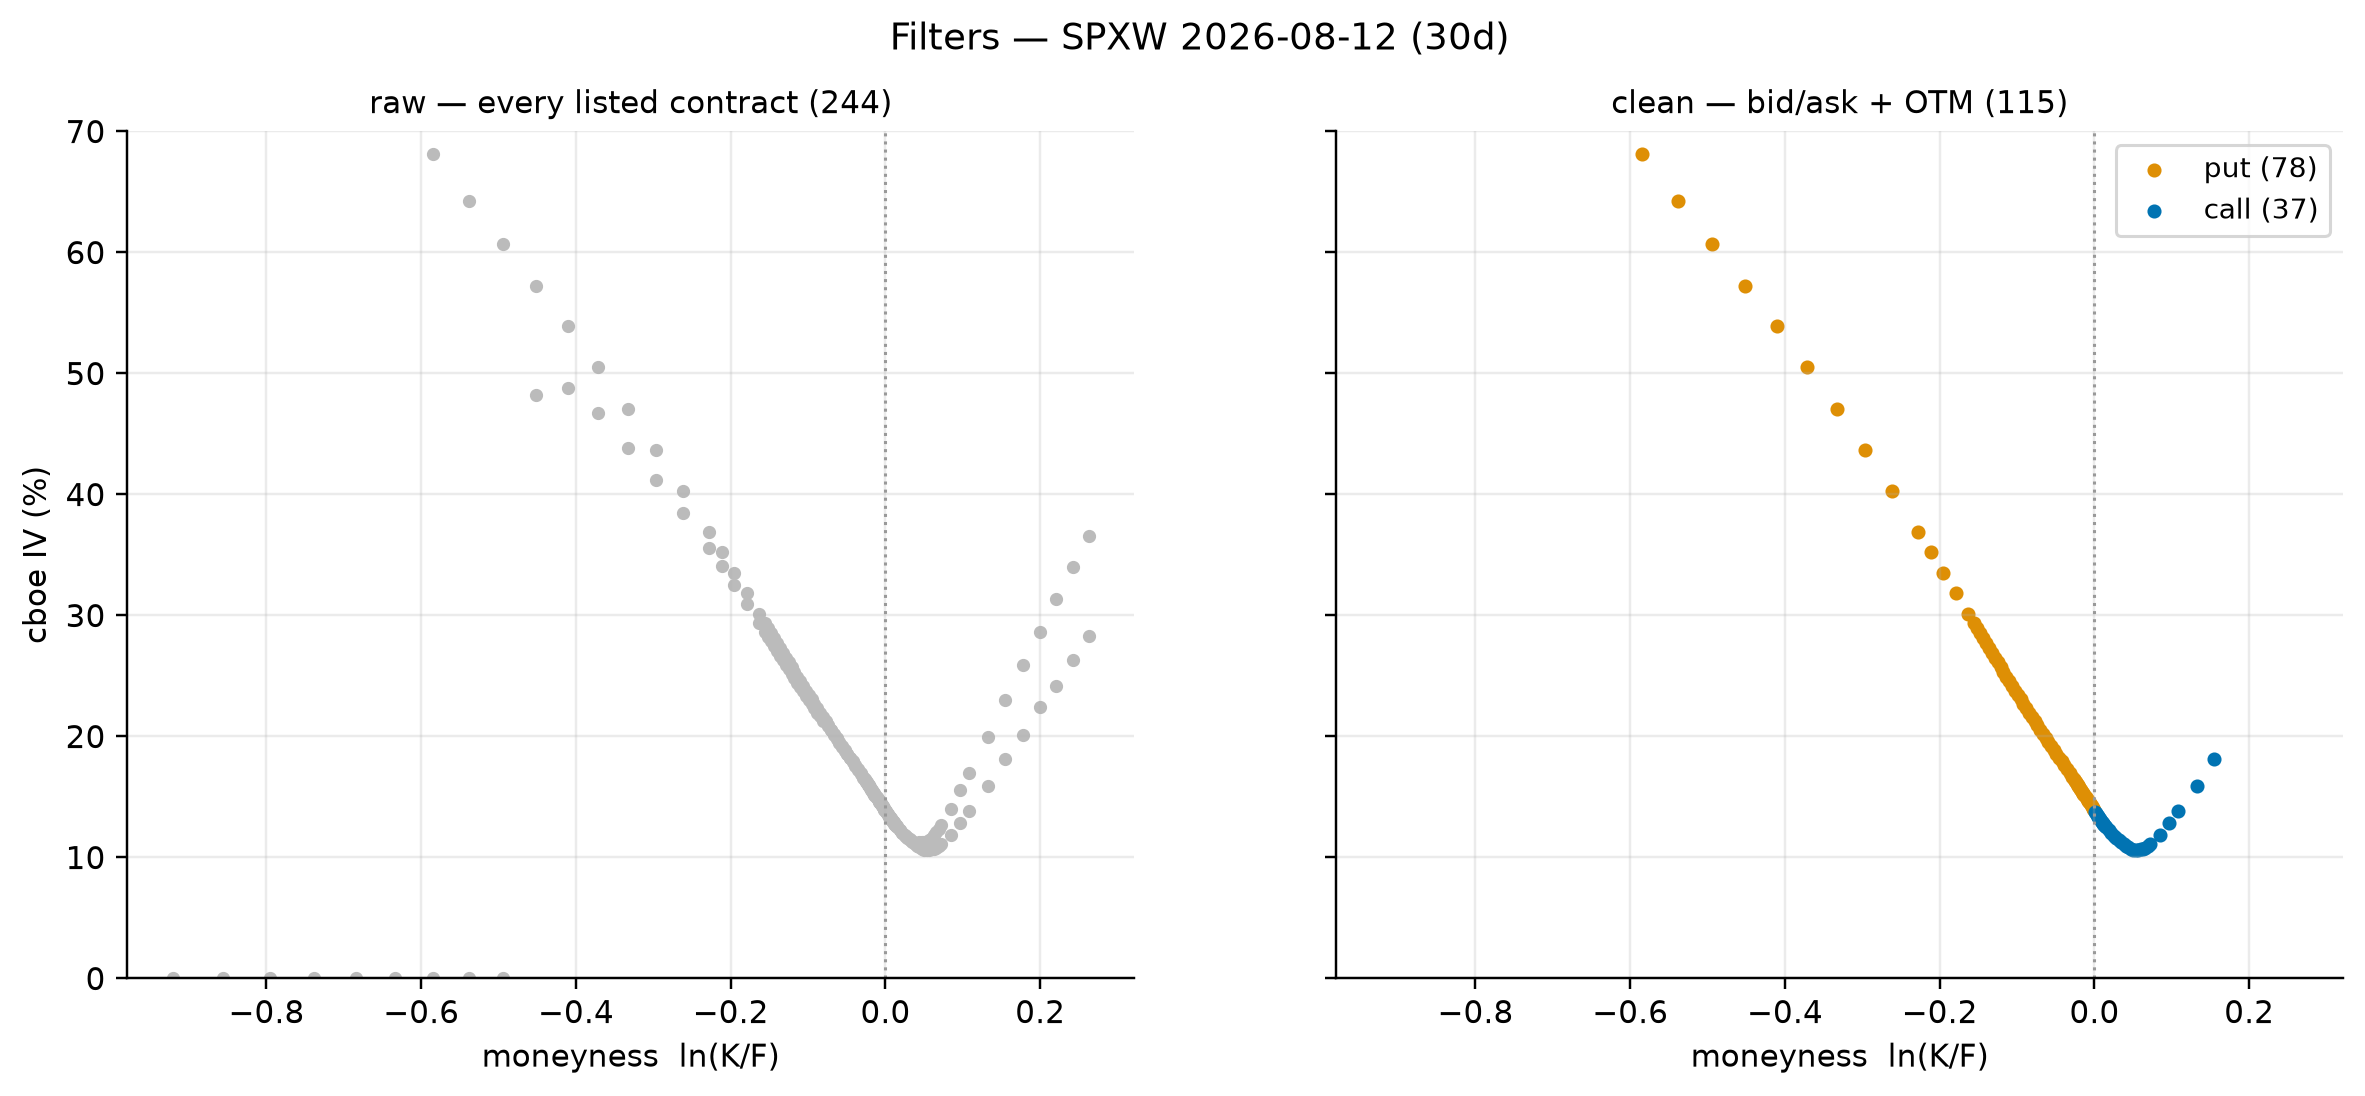

In [63]:
base = df[(df["expiry"] == exp30) & (df["root"] == root30)].copy()
Fexp = forward_by_expiry(qf).iloc[0]
base["m"] = np.log(base["strike"] / Fexp)
otm = (((base["type"] == "P") & (base["strike"] < Fexp)) |
       ((base["type"] == "C") & (base["strike"] > Fexp)))
clean = bidask_mask(base) & otm

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
axes[0].scatter(base["m"], base["cboe_iv"] * 100, s=11, color=C_DROP)
axes[0].set_title(f"raw — every listed contract ({len(base)})", fontsize=10)
kp = base[clean & (base["type"] == "P")]
kc = base[clean & (base["type"] == "C")]
axes[1].scatter(kp["m"], kp["cboe_iv"] * 100, s=13, color=C_PUT, label=f"put ({len(kp)})")
axes[1].scatter(kc["m"], kc["cboe_iv"] * 100, s=13, color=C_CALL, label=f"call ({len(kc)})")
axes[1].set_title(f"clean — bid/ask + OTM ({int(clean.sum())})", fontsize=10)
axes[1].legend(fontsize=9)
for ax in axes:
    ax.axvline(0, color="#999", lw=1, ls=":")
    ax.set_ylim(0, 70)
    ax.set_xlabel("moneyness  ln(K/F)")
axes[0].set_ylabel("cboe IV (%)")
fig.suptitle(f"Filters — {root30} {pd.Timestamp(exp30).date()} ({d30}d)", fontsize=12)
plt.show()

## 5. The smile

One ~30-day expiry, cleaned: OTM puts (below the forward) and OTM calls (above), on the
moneyness axis. The downward slope to the left is the equity **skew** — crash protection
is bid up, so out-of-the-money puts carry higher IV than calls.

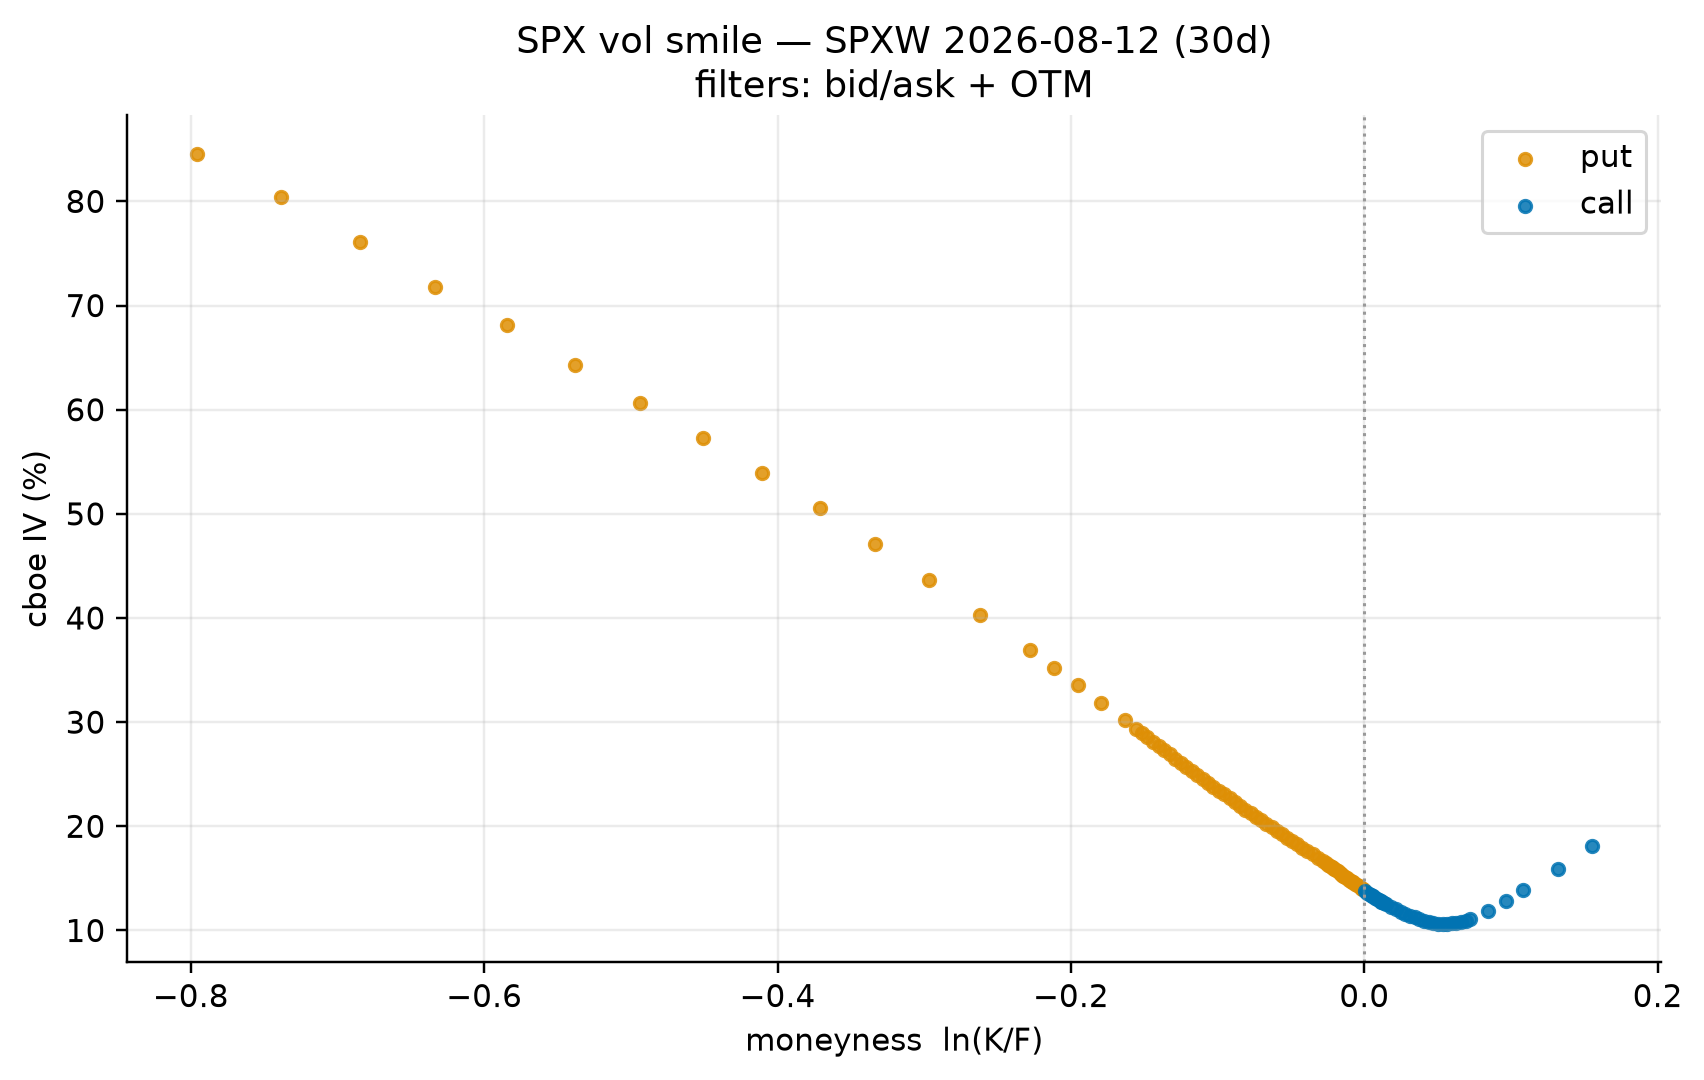

In [64]:
_, _, sl30, _ = pick_slice(CLEAN, 30)
fig, ax = plt.subplots(figsize=(9, 5))
for t, c, lab in [("P", C_PUT, "put"), ("C", C_CALL, "call")]:
    s = sl30[sl30["type"] == t].sort_values("m")
    ax.scatter(s["m"], s["cboe_iv"] * 100, s=16, color=c, label=lab, alpha=0.85)
ax.axvline(0, color="#999", lw=1, ls=":")
ax.set_xlabel("moneyness  ln(K/F)")
ax.set_ylabel("cboe IV (%)")
ax.set_title(f"SPX vol smile — {root30} {pd.Timestamp(exp30).date()} ({d30}d)\n"
             f"filters: bid/ask + OTM")
ax.legend()
plt.show()

## 6. Term structure — skew flattens with maturity

The same clean smile at ~30 / 90 / 180 / 365 days, blended across roots. Near-term skew
is steepest (a shock matters most when there's little time to recover); as maturity
grows the smile flattens and lifts. This 2-D fan is one moneyness-slice of the full
`(moneyness, T)` surface.

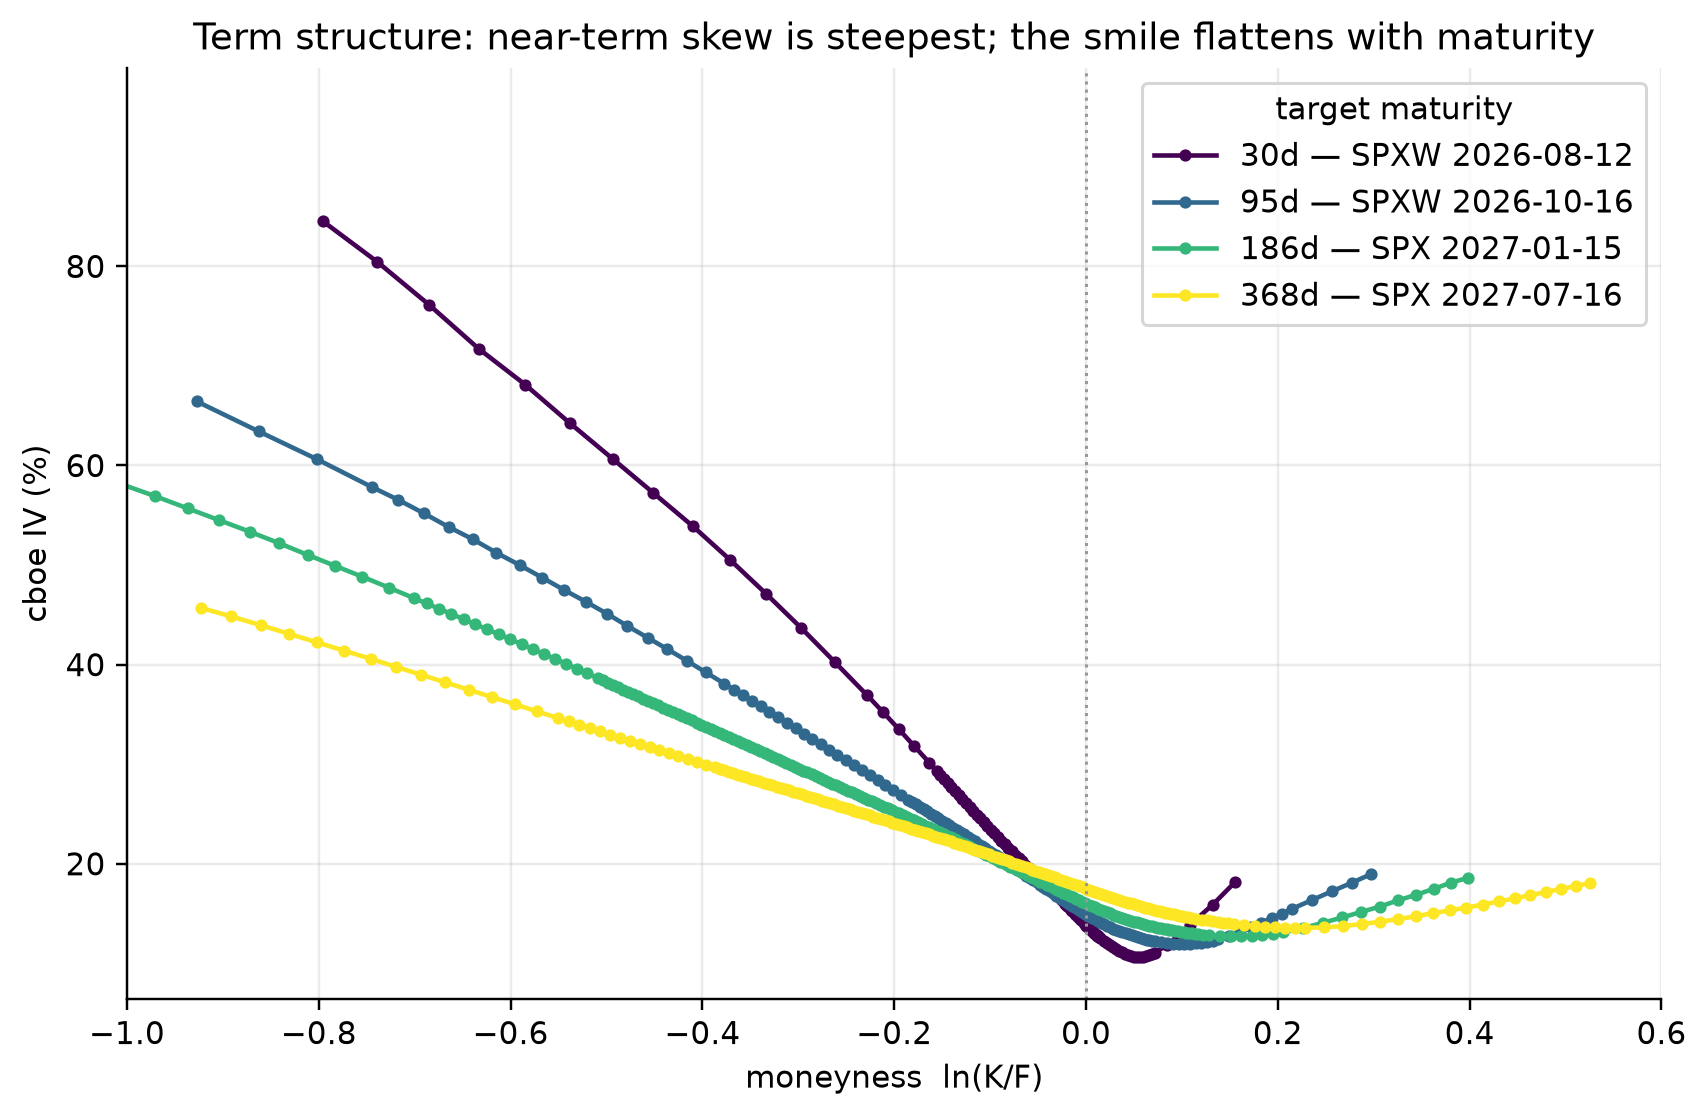

In [65]:
targets = [30, 90, 180, 365]
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, td in enumerate(targets):
    exp, dd, sl, root = pick_slice(CLEAN, td)
    s = sl.sort_values("m")
    ax.plot(s["m"], s["cboe_iv"] * 100, "-o", ms=3,
            color=cmap(i / (len(targets) - 1)),
            label=f"{dd}d — {root} {pd.Timestamp(exp).date()}")
ax.axvline(0, color="#999", lw=1, ls=":")
ax.set_xlim(-1.0, 0.6)
ax.set_xlabel("moneyness  ln(K/F)")
ax.set_ylabel("cboe IV (%)")
ax.set_title("Term structure: near-term skew is steepest; the smile flattens with maturity")
ax.legend(title="target maturity")
plt.show()

---
### Where this goes next

What you've seen is the **raw** cleaned surface — CBOE's IV on real, liquid quotes. Its
moneyness coverage is deliberately **ragged**: narrow near-term wings, wide in the middle,
sparse far out (liquidity, scaling with √T). The next milestones consolidate it into a
smooth, arbitrage-free surface (see `docs/STATE.md`):

- our own **Black-Scholes IV** solver, swapped in for `cboe_iv`;
- an **SVI/SSVI fit** — fills the ragged wings into a consistent `(moneyness, T)` grid, √T scaling built in;
- a **no-arbitrage** (monotonicity) check.

Deferred cleaning: the median+MAD spread-outlier filter.

*Decisions behind this notebook: ADR 001 (data) · 003 (parity forward) · 004 (root blend)
· 006 (cboe_iv v1) · 008 (filters).*